# Logistic Regression Exercise

Now it's your turn to implement logistic regression on a new data set. For this purpose we use the Titanic Dataset. It includes personal information of all passengers on the Titanic as well as they survived the sinking of the Titanic or died.

Here’s the **Data Dictionary** of the dataset:

- PassengerID: type should be integers

- Survived: survived or not

- Pclass: class of Travel of every passenger

- Name: the name of the passenger

- Sex: gender

- Age: age of passengers

- SibSp: No. of siblings/spouse aboard

- Parch: No. of parent/child aboard

- Ticket: Ticket number

- Fare: what Prices they paid

- Cabin: cabin number

- Embarked: the port in which a passenger has embarked.

        - C: Cherbourg , S: Southampton , Q: Queenstown


You will find the data in the data folder.


## What you should do:

- conduct a brief EDA to become familiar with the data
- use Logistic Regression to predict if a passenger died or not

## How to do it:

Time is short, so aim for the simplest viable product first:
1. Load the data

2. Separate features and target 

3. Split the data in train and test

3. Get a quick overview of the train data

4. Agree on a classification metric for the task 

5. Create a simple heuristic/educated guess for the classification first. This is called a "baseline model". It is used to compare more complex models later (in this case: logistic regression). You as a data scientist want to prove how much your work/ML could improve the business metric, therefore you need a baseline model for comparison. In some cases you want to improve on an already existing model in your company which would be your baseline model then. In other cases, there are typical baseline models used in the specific field. For other tasks, you have to come up with a simple but meaningful idea, how to classify the data based on your business understanding (EDA). A baseline model should follow Occam’s Razor principle: "A simple model is the best model". 
    - Example of a baseline model: 
    If the task is to classify cats and dogs, a baseline model could be: We classify every animal as cat if its weight < 5 kg, otherwise the animal is classified as a dog. (The value of 5 kg is an educated guess, based on our business understanding/EDA.) 

6. use one or two already numerical features to create a simple first model
    -  did it even beat your base model?

7. Now you can go through the data science lifecycle again and again:
    - clean the data better

    - get more insights with EDA

    - add more features

    - do feature engineering 
    
    and check if your work improves your model further!

8. Stop whenever time is up or you cannot improve your model any further.

This repository contains a solution to this problem. If you want to compare your final result with the result of this repository solution, choose **25** as random seed and a test size of 30% for your train test split.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

%matplotlib inline
pd.set_option("display.max_columns", None)

In [2]:
titanic = pd.read_csv("data/titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
y = titanic["Survived"]
X = titanic.drop("Survived", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=25
)

print(X_train.shape, X_test.shape)

(623, 11) (268, 11)


In [4]:
train = X_train.copy()
train["Survived"] = y_train

train.info()
print("\nMissing values:")
print(train.isna().sum()[lambda s: s > 0])
print("\nSurvival rate overall:")
print(train["Survived"].value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
Index: 623 entries, 707 to 132
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  623 non-null    int64  
 1   Pclass       623 non-null    int64  
 2   Name         623 non-null    str    
 3   Sex          623 non-null    str    
 4   Age          492 non-null    float64
 5   SibSp        623 non-null    int64  
 6   Parch        623 non-null    int64  
 7   Ticket       623 non-null    str    
 8   Fare         623 non-null    float64
 9   Cabin        137 non-null    str    
 10  Embarked     622 non-null    str    
 11  Survived     623 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 63.3 KB

Missing values:
Age         131
Cabin       486
Embarked      1
dtype: int64

Survival rate overall:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


Survival rate by sex:
Sex
female    0.748
male      0.182
Name: Survived, dtype: float64

Survival rate by class:
Pclass
1    0.628
2    0.452
3    0.260
Name: Survived, dtype: float64


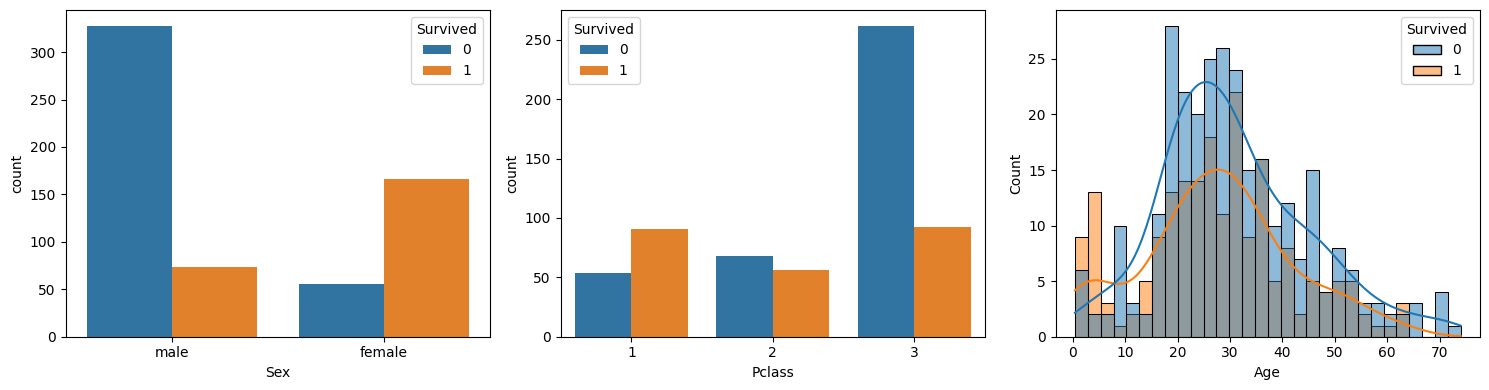

In [5]:
print("Survival rate by sex:")
print(train.groupby("Sex")["Survived"].mean().round(3))
print("\nSurvival rate by class:")
print(train.groupby("Pclass")["Survived"].mean().round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=train, x="Sex", hue="Survived", ax=axes[0])
sns.countplot(data=train, x="Pclass", hue="Survived", ax=axes[1])
sns.histplot(data=train, x="Age", hue="Survived", bins=30, kde=True, ax=axes[2])
plt.tight_layout()

Metric: accuracy as the headline, with F1 alongside. The classes are only moderately imbalanced (roughly 62% died / 38% survived), so accuracy is meaningful here — but F1 keeps an eye on how well the model identifies survivors specifically, which accuracy alone can hide.

In [6]:
# Baseline heuristic from the EDA: predict that every woman survived, every man died.
baseline_pred = (X_test["Sex"] == "female").astype(int)

baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

print(f"Baseline — accuracy: {baseline_acc:.4f}   F1: {baseline_f1:.4f}")

Baseline — accuracy: 0.7724   F1: 0.6872


In [7]:
simple_features = ["Pclass", "Fare"]

simple_model = LogisticRegression(max_iter=1000, random_state=25)
simple_model.fit(X_train[simple_features], y_train)

simple_pred = simple_model.predict(X_test[simple_features])

print(f"Simple model — accuracy: {accuracy_score(y_test, simple_pred):.4f}   F1: {f1_score(y_test, simple_pred):.4f}")
print(f"Baseline     — accuracy: {baseline_acc:.4f}   F1: {baseline_f1:.4f}")

Simple model — accuracy: 0.6978   F1: 0.5318
Baseline     — accuracy: 0.7724   F1: 0.6872


In [8]:
def prepare(df, age_median, fare_median, embarked_mode):
    """Clean, engineer and encode. Imputation values come from the TRAINING set only."""
    d = df.copy()

    # fill the gaps
    d["Age"] = d["Age"].fillna(age_median)
    d["Fare"] = d["Fare"].fillna(fare_median)
    d["Embarked"] = d["Embarked"].fillna(embarked_mode)

    # engineered features
    d["FamilySize"] = d["SibSp"] + d["Parch"] + 1
    d["IsAlone"] = (d["FamilySize"] == 1).astype(int)
    d["HasCabin"] = d["Cabin"].notna().astype(int)

    # drop the free-text / identifier columns
    d = d[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare",
           "Embarked", "FamilySize", "IsAlone", "HasCabin"]]

    return pd.get_dummies(d, columns=["Sex", "Embarked"], drop_first=True)


# Learn the imputation values from the training set
age_median = X_train["Age"].median()
fare_median = X_train["Fare"].median()
embarked_mode = X_train["Embarked"].mode()[0]

X_train_prep = prepare(X_train, age_median, fare_median, embarked_mode)
X_test_prep = prepare(X_test, age_median, fare_median, embarked_mode)

# guarantee the test set has exactly the same columns, in the same order
X_test_prep = X_test_prep.reindex(columns=X_train_prep.columns, fill_value=0)

full_model = LogisticRegression(max_iter=1000, random_state=25)
full_model.fit(X_train_prep, y_train)

full_pred = full_model.predict(X_test_prep)

print(f"Full model — accuracy: {accuracy_score(y_test, full_pred):.4f}   F1: {f1_score(y_test, full_pred):.4f}")

Full model — accuracy: 0.7799   F1: 0.7065


                       model  accuracy     f1
Baseline (all women survive)    0.7724 0.6872
    Logistic — Pclass + Fare    0.6978 0.5318
     Logistic — all features    0.7799 0.7065 

              precision    recall  f1-score   support

        died       0.81      0.84      0.82       165
    survived       0.72      0.69      0.71       103

    accuracy                           0.78       268
   macro avg       0.77      0.76      0.77       268
weighted avg       0.78      0.78      0.78       268


Coefficients:
Sex_male     -2.589
IsAlone      -0.719
Pclass       -0.632
FamilySize   -0.310
SibSp        -0.289
Embarked_S   -0.233
Age          -0.048
Embarked_Q   -0.028
Parch        -0.019
Fare          0.003
HasCabin      0.756
dtype: float64


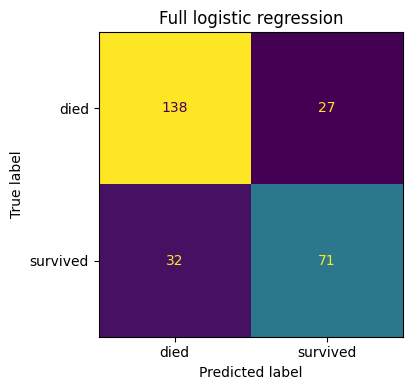

In [9]:
results = pd.DataFrame({
    "model": ["Baseline (all women survive)", "Logistic — Pclass + Fare", "Logistic — all features"],
    "accuracy": [baseline_acc, accuracy_score(y_test, simple_pred), accuracy_score(y_test, full_pred)],
    "f1": [baseline_f1, f1_score(y_test, simple_pred), f1_score(y_test, full_pred)],
}).round(4)

print(results.to_string(index=False), "\n")
print(classification_report(y_test, full_pred, target_names=["died", "survived"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, full_pred, display_labels=["died", "survived"], ax=ax, colorbar=False
)
ax.set_title("Full logistic regression")
plt.tight_layout()

print("\nCoefficients:")
print(pd.Series(full_model.coef_[0], index=X_train_prep.columns).sort_values().round(3))

Metric. Accuracy as the headline, F1 alongside — the split is roughly 62% died / 38% survived, imbalanced enough that accuracy alone could flatter a lazy model.

Baseline. "Every woman survived, every man died" — one rule, taken straight from the survival-by-sex table, no fitting at all. It scored 0.7724 accuracy / 0.6872 F1.

Simple model. Logistic regression on Pclass and Fare only reached 0.6978 / 0.5318 — clearly worse than the baseline. Both variables are proxies for wealth, and neither carries the sex information that drives survival, so the model was handicapped from the start.

Full model. Adding sex, imputed age, embarkation port and the engineered FamilySize, IsAlone and HasCabin features brought it to 0.7799 / 0.7065, finally ahead of the baseline.

How much did the modelling actually buy us? Very little on accuracy: 0.7724 → 0.7799 is 2 extra passengers correct out of 268. The F1 gain is more real (0.6872 → 0.7065), meaning the model identifies survivors somewhat better than the blanket rule. But the honest conclusion is that a single sensible heuristic gets you most of the way, and eleven features and a fitted model add a modest amount on top. That's exactly the comparison a baseline exists to expose.

What the coefficients say. Sex_male at −2.589 dwarfs everything else — it's more than three times the next largest, which is why the sex-only baseline was so hard to beat: the model is largely rediscovering that same rule and adjusting around the edges. HasCabin (+0.756) is the strongest positive: a recorded cabin number signals wealth beyond what Pclass alone captures. IsAlone (−0.719) and Pclass (−0.632) follow — passengers travelling alone and in lower classes were less likely to survive.

Where it goes wrong. The confusion matrix shows 138 correctly predicted deaths and 71 correct survivals, against 32 survivors the model wrote off as dead and 27 deaths it predicted as survivals. The errors are fairly balanced, but the 32 missed survivors are why recall on the survived class sits at 0.69.